# ML - ARBOL DE DECISION (EDA)

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Paso 1: Definicion del problema (target)
El objetivo es predecir si un paciente tiene o no diabetes, la tenemos localizada en la variable `Outcome`

## Paso 2: Recopilacion de datos
[fuente](https://raw.githubusercontent.com/4GeeksAcademy/decision-tree-project-tutorial/main/diabetes.csv)

### Importamos los datos y creamos el DataFrame

In [3]:
df = pd.read_csv('../data/raw/diabetes.csv')
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


## Paso 3: Realizamos un EDA completo

### Analisis descriptivo

In [4]:
# Obtenemos las dimensiones
df.shape

(768, 9)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [6]:
# Comprobamos si hay valores unknown, no deberiam aparecer ya que todas son numericas
unknown = df.isin(['unknown']).sum()

In [7]:
# Obtenemos información estadística de las variables
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


> ## Observaciones:
>
> - Existen un total de 768 filas (en este caso, pacientes) y 9 columnas, entre las cuales esta nuestra variable objetivo `Outcome`
> - Todas las variables son numéricas

### Limpieza de datos

In [8]:
# Comprobamos si hay valores duplicados
df[df.duplicated()]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome


In [9]:
df.duplicated().sum()

np.int64(0)

> ## Observaciones:
>
> - No existen registros duplicados
> - De momento no vamos a eliminar ninguna variable, todas pueden aportar inforamcion significativa para el analisis

### Análisis de Variables

#### Análisis de Variables Univariantes Numéricas

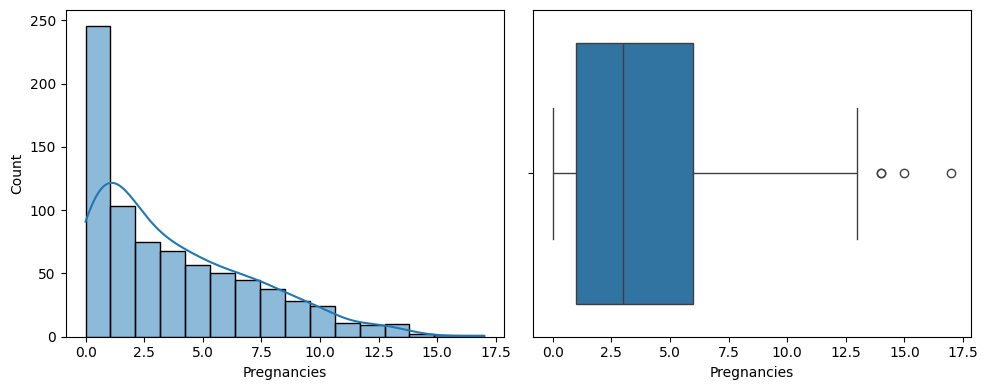

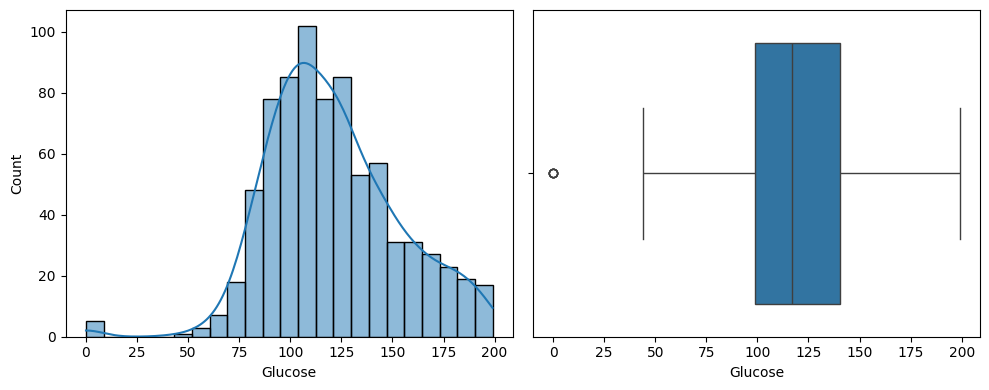

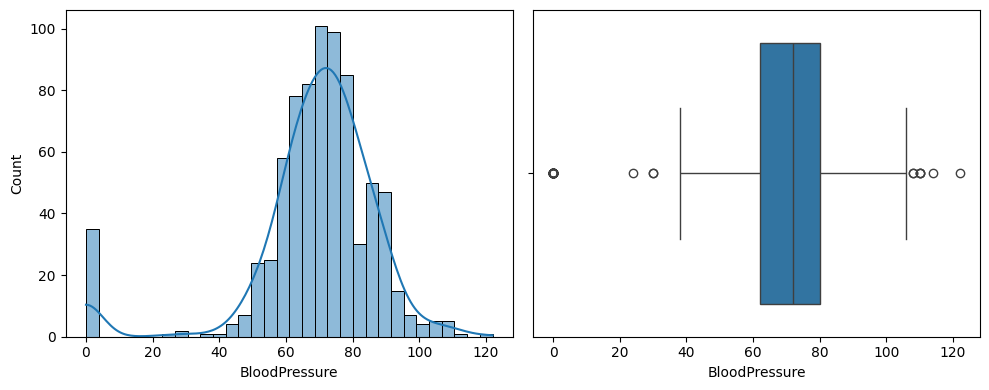

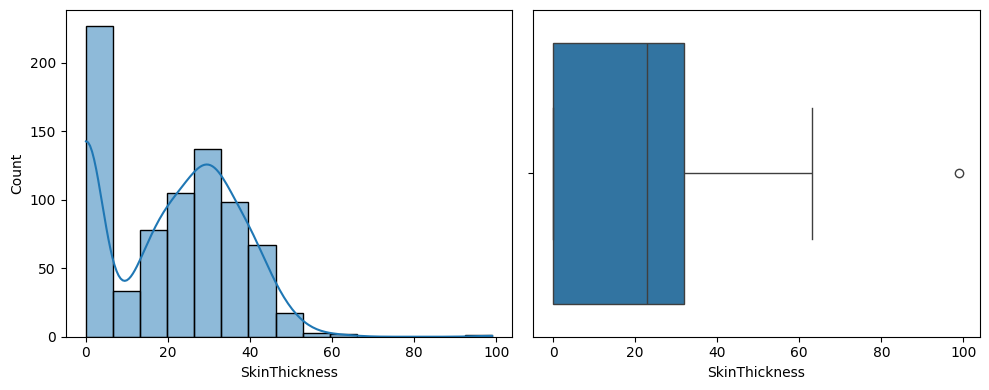

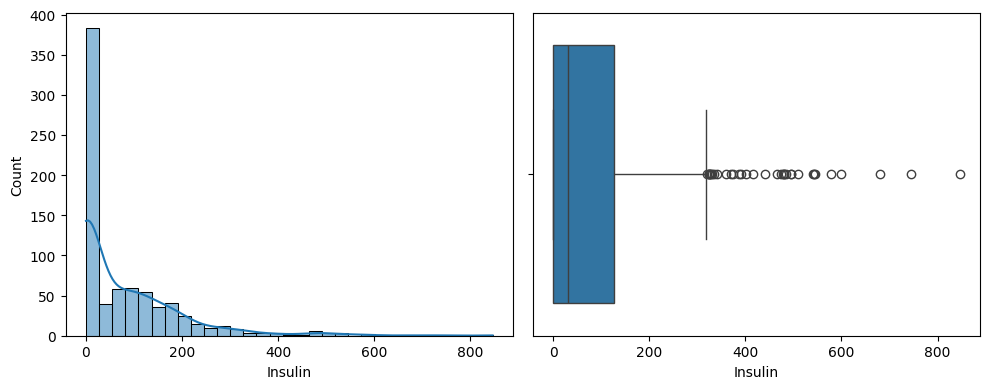

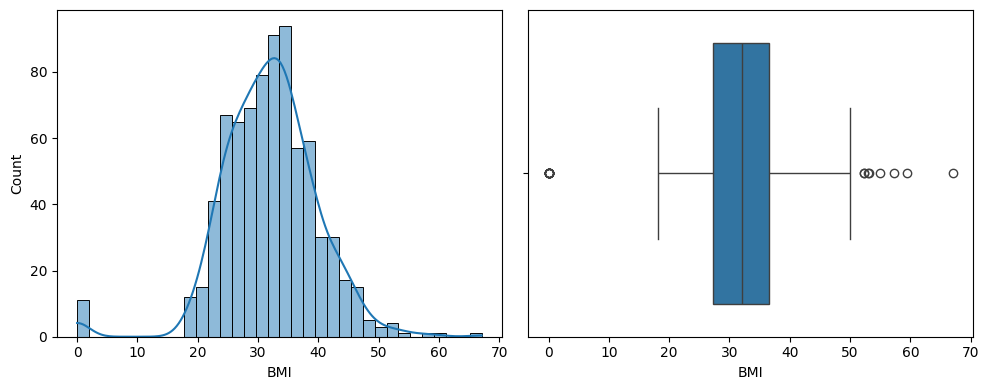

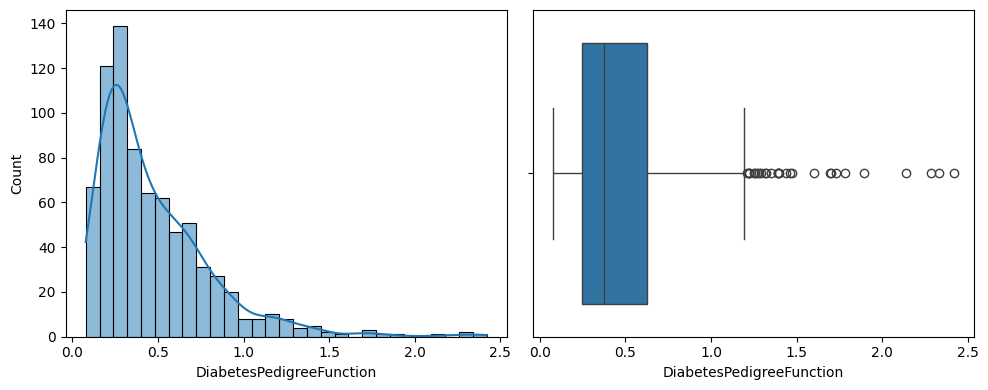

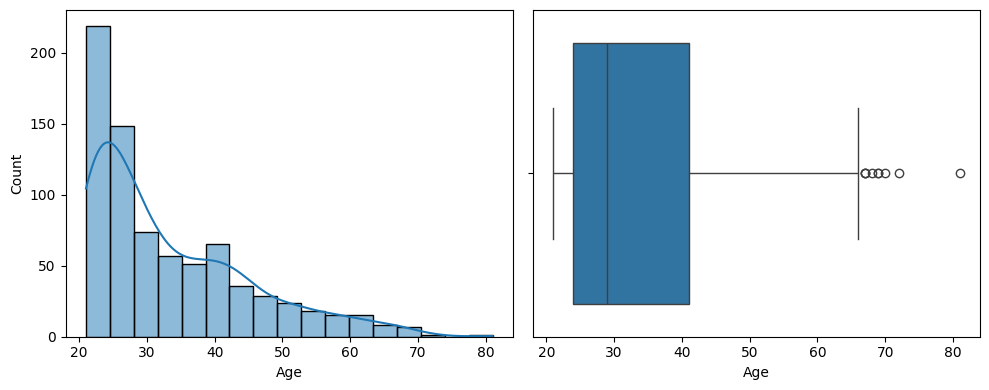

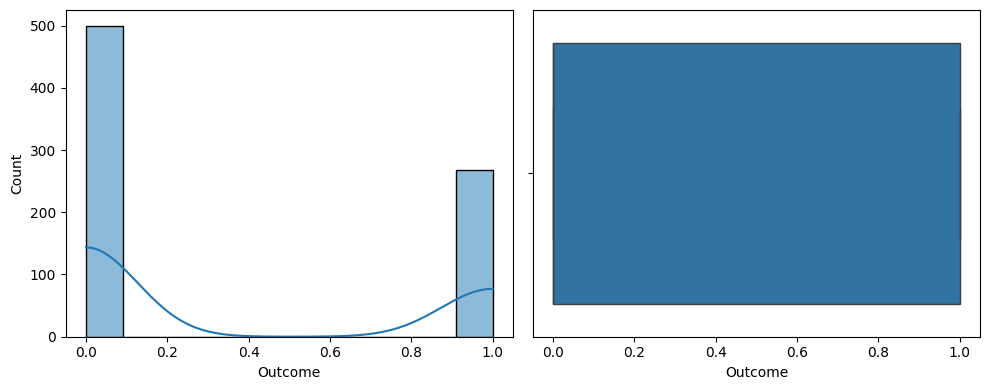

In [10]:
for col in df.columns:
    plt.figure(figsize=(10, 4)) 

    plt.subplot(1, 2, 1) 
    sns.histplot(data=df, x=col, kde=True)

    plt.subplot(1, 2, 2)  
    sns.boxplot(data=df, x=col)

    plt.tight_layout()

#### Análisis de Variables Multivariante (numerico-numerico)

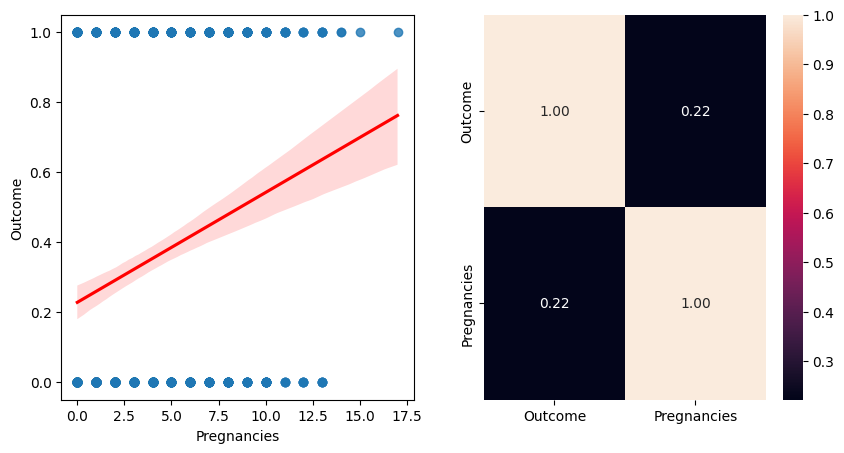

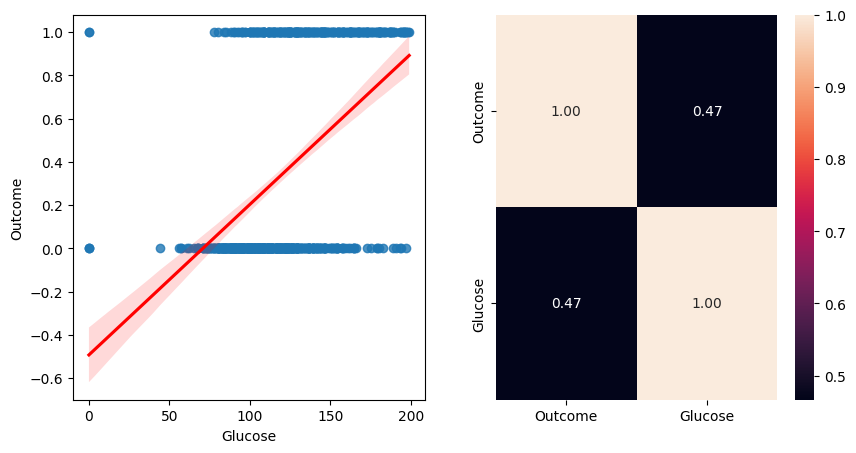

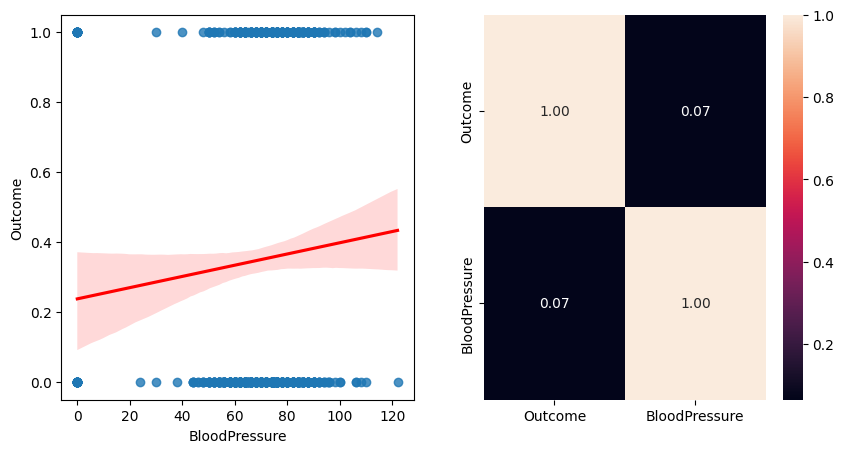

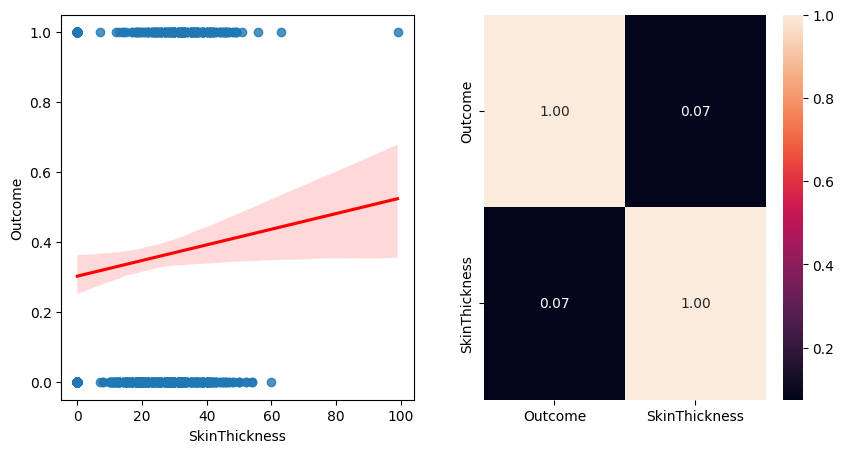

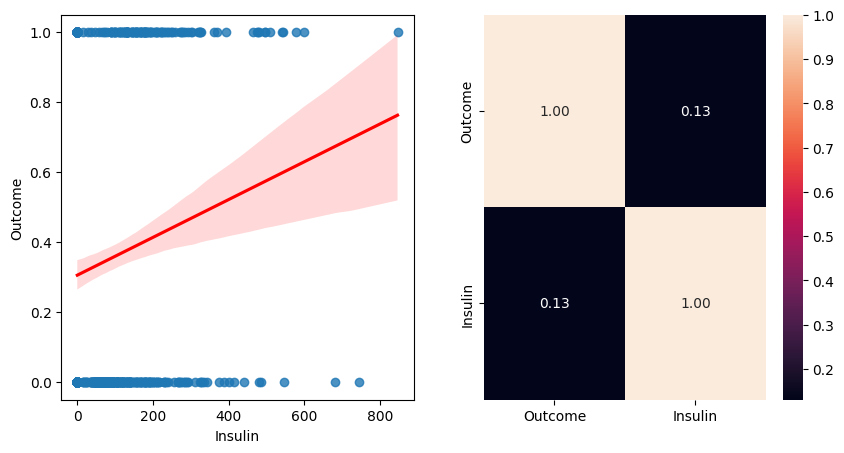

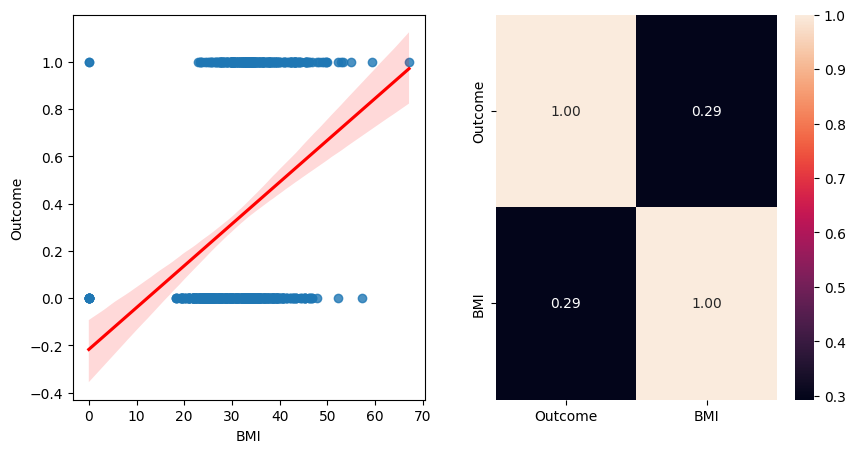

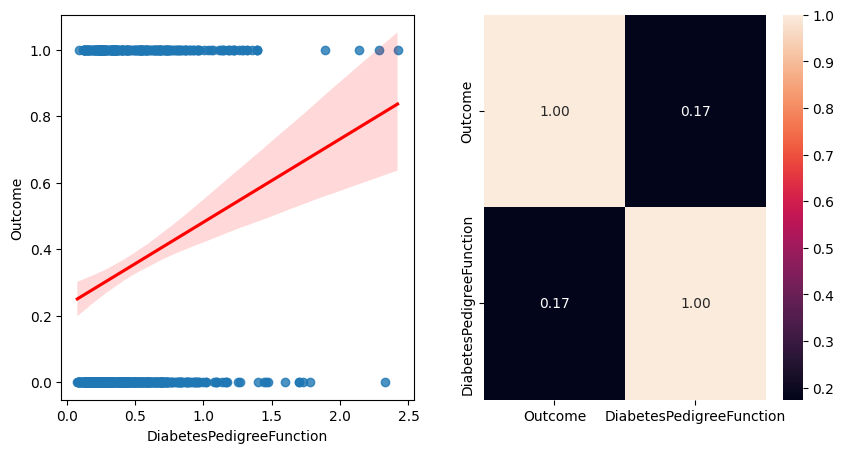

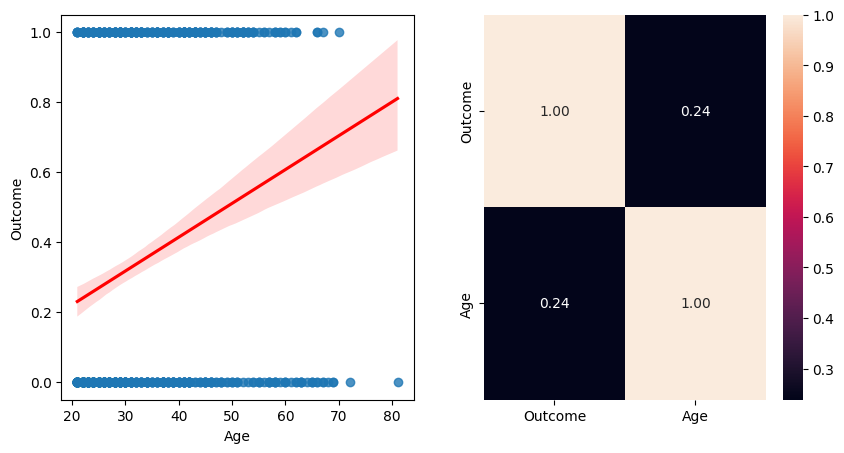

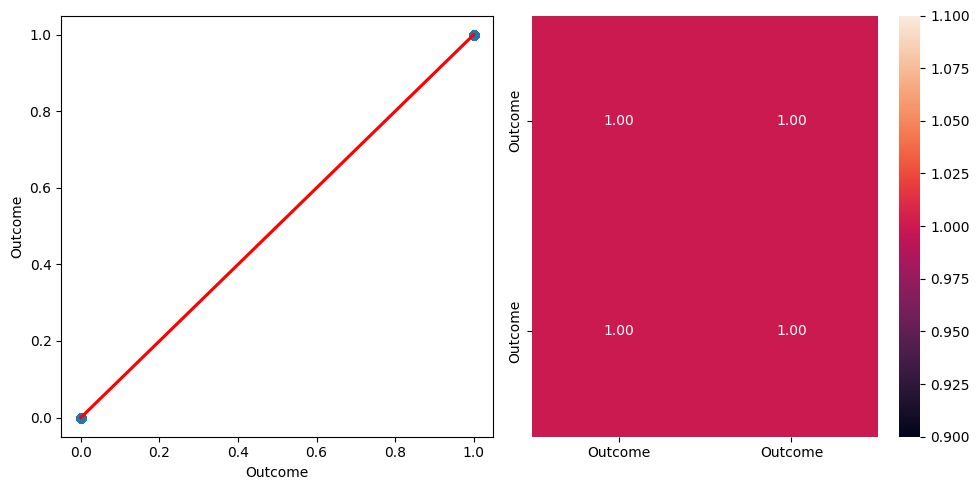

In [11]:
for col in df.columns:
    plt.figure(figsize=(10, 5)) 

    plt.subplot(1, 2, 1) 
    sns.regplot(data=df, x=col, y='Outcome', line_kws={'color': 'red'})

    plt.subplot(1, 2, 2)  
    sns.heatmap(df[['Outcome', col]].corr(), annot=True, fmt='.2f')

plt.tight_layout()

<Axes: >

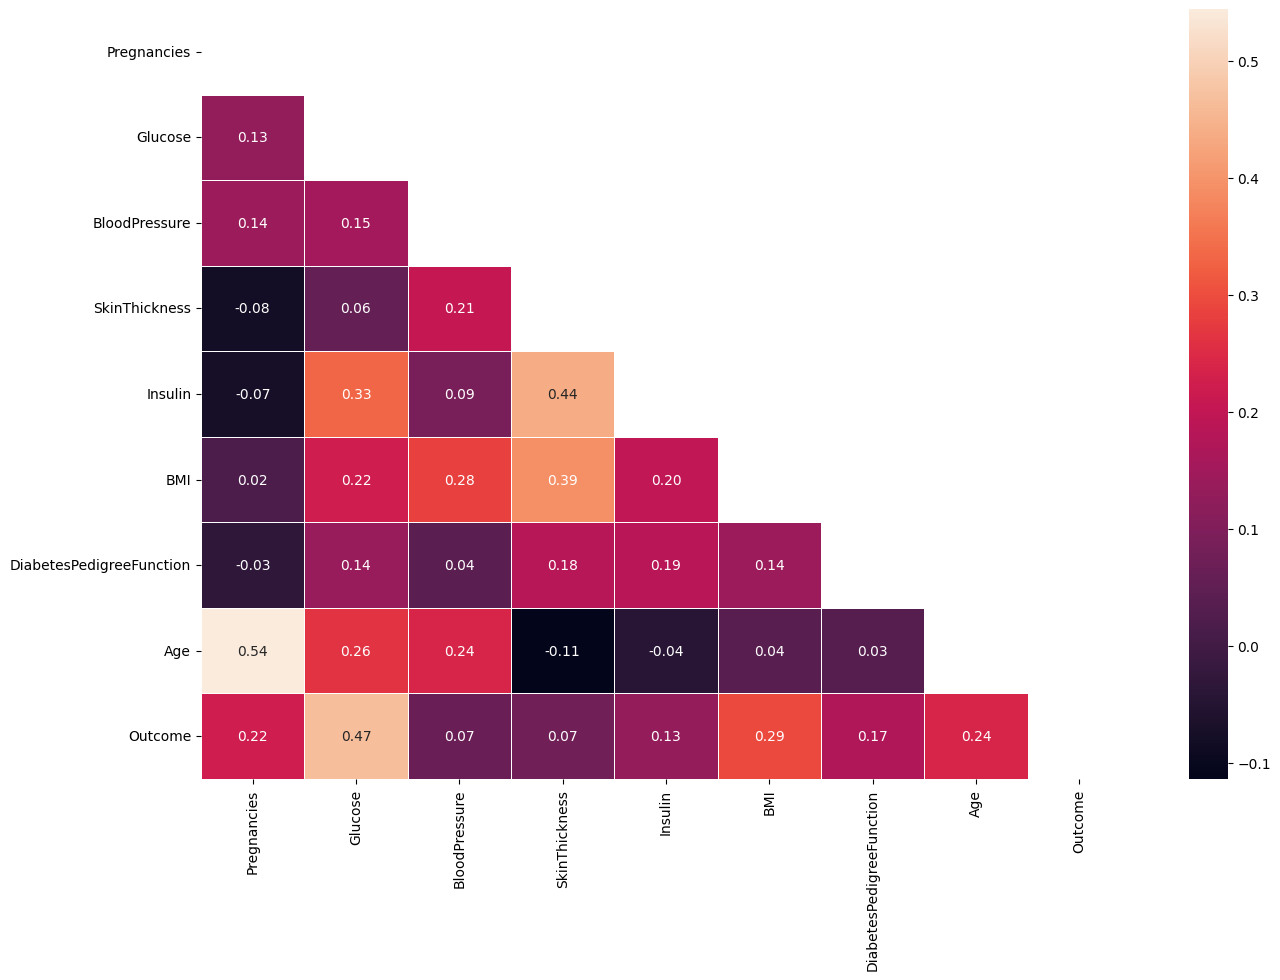

In [12]:
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, axis = plt.subplots(figsize=(15, 10))
sns.heatmap(corr, mask=mask, annot=True, linewidths=0.5, fmt='.2f')